# Why do stock markets make their money *overnight*? 🌙
### A real market anomaly — and why it's subtler than it looks

Over the last 30 years, almost all the gains of the world's big stock markets piled up **while the market was closed** (from one day's close to the next morning's open). The **daytime session** (open → close) is nearly flat. Strange, isn't it?

This notebook tells the story **without jargon**. For the rigorous version (real data, statistics, costs), head to [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).

> ⚠️ **This is not investment advice.** Educational and research tool.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")


## 1. The pattern: the night rises, the day stalls

Let's build a *toy* market that is completely honest: each night it drifts a hair upward (+3 basis points, i.e. +0.03%), each day a hair downward, and **everything else is pure noise — no fraud, no conspiracy**. What does the night/day decomposition show?

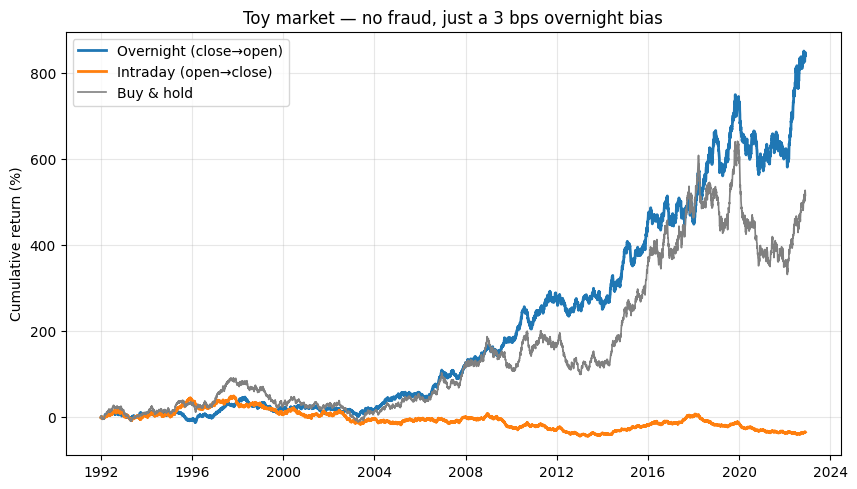

Overnight cumulative: +840%   Intraday cumulative: -35%


In [2]:
from overnight import decompose, diagnostics

ohlc = diagnostics.synthetic_ohlc(overnight_bias_bps=3, intraday_bias_bps=-1, seed=0)
dec = decompose.decompose(ohlc)

ax = plt.subplot()
ax.plot(dec.index, dec['cum_overnight']*100, label='Overnight (close→open)', lw=2)
ax.plot(dec.index, dec['cum_intraday']*100, label='Intraday (open→close)', lw=2)
ax.plot(dec.index, dec['cum_close_close']*100, label='Buy & hold', color='grey', lw=1.2)
ax.set_title('Toy market — no fraud, just a 3 bps overnight bias')
ax.set_ylabel('Cumulative return (%)'); ax.legend(); ax.grid(alpha=.3)
plt.show()
s = decompose.summary(dec)
print(f"Overnight cumulative: {s.loc['overnight','cum_return']*100:+.0f}%   "
      f"Intraday cumulative: {s.loc['intraday','cum_return']*100:+.0f}%")

**We just reproduced Knuteson's pattern with zero manipulation.** A tiny constant bias, repeated ~250 nights a year for 32 years, is enough. The night *looks* magical. Hold that thought: a very small edge, repeated thousands of times, becomes huge. That's our first trap.

## 2. Trap #1 — the scale lies (the magic of compounding)

The article's charts use a **logarithmic** scale, where you quickly read "billions of %". But where does that dizzying number come from? Not from fraud: from **compounding**. Look at what a simple constant bias becomes, by size and horizon:

In [3]:
table = diagnostics.compounding_table()
diagnostics.format_compounding(table)

,~10y,~20y,~32y
1 bps/night,+29%,+66%,+124%
5 bps/night,+252%,"+1,142%","+5,532%"
10 bps/night,"+1,141%","+15,308%","+316,420%"
30 bps/night,"+189,724%",+360M%,+3.1tn%


A bias of **1 basis point per night** — totally innocent, undetectable — compounds to three digits over 30 years. At 30 bps, you reach *trillions* of percent. **The explosion comes from the exponent, not from a conspiracy.** Any spectacular magnitude shown on a log axis must pass this sanity check first.

## 3. Trap #2 — dirty data manufactures the signal

Free data (Yahoo) mis-handles some *splits* and dividends, especially in emerging markets. A handful of corrupted prices is enough to **mechanically shift return from the day into the night**. Demonstration on a perfectly flat market (zero bias) where we dirty 3 prices:

In [4]:
flat = diagnostics.synthetic_ohlc(overnight_bias_bps=0, intraday_bias_bps=0, seed=1)
clean = decompose.decompose(flat)
dirty = decompose.decompose(diagnostics.inject_split_artifact(flat, factor=1.5))
print(f"Overnight cumulative  BEFORE: {clean['cum_overnight'].iloc[-1]*100:+.1f}%")
print(f"Overnight cumulative  AFTER : {dirty['cum_overnight'].iloc[-1]*100:+.1f}%   (3 dirtied prices)")
flags = diagnostics.flag_suspicious_returns(dirty)
print(f"\nThe automatic detector flags {len(flags)} suspicious day(s):")
flags[['r_overnight','r_intraday']]

Overnight cumulative  BEFORE: -56.0%
Overnight cumulative  AFTER : +48.6%   (3 dirtied prices)

The automatic detector flags 3 suspicious day(s):


,r_overnight,r_intraday
1999-09-23,0.508,-0.337
2015-03-09,0.504,-0.335
2007-06-15,0.493,-0.341


Three data errors, and the "overnight performance" flips from red to bright green. This is exactly the mechanism behind the wild numbers of certain emerging markets in the article. **Before crying scandal, check your data.**

## 4. Trap #3 — fees erase the gain

Suppose the night effect is real (it partly is). Can you *trade* it? The "buy at the close, sell at the open" strategy pays the bid/ask spread **twice a day, ~250 days a year**. Let's see what's left once we subtract realistic costs:

In [5]:
from overnight import backtest
sweep = backtest.cost_sweep(dec, roundtrip_bps=(0,1,2,3,5,8))
view = sweep.copy()
view['cagr_net'] = (view['cagr_net']*100).map('{:+.2f}%'.format)
view['sharpe_net'] = view['sharpe_net'].map('{:+.2f}'.format)
view['max_drawdown'] = (view['max_drawdown']*100).map('{:.0f}%'.format)
view.columns = ['Net annual return', 'Net Sharpe', 'Worst drawdown']
view.index.name = 'Round-trip cost (bps)'
view

,Net annual return,Net Sharpe,Worst drawdown
Round-trip cost (bps),,,
0,+7.25%,+0.68,-31%
1,+4.59%,+0.45,-39%
2,+1.98%,+0.23,-48%
3,-0.55%,+0.01,-61%
5,-5.44%,-0.44,-87%
8,-12.33%,-1.11,-99%


At **0 fees**, the Sharpe is decent (~0.7). At a realistic **5 basis points** round-trip, the gain turns **negative**. This is precisely the fate of the "night effect" ETFs NSPY and NIWM: launched June 2022, **liquidated August 2023** after heavy underperformance.

> *A strategy that's beautiful on paper is worth no more than the paper until it has paid the real costs of execution.*

## In a nutshell

| | |
|---|---|
| ✅ **The fact is real** | the night did outperform the day, over decades |
| ⚠️ **But the numbers are inflated** | compounding + log scale + dirty data |
| ❌ **And hard to exploit** | fees erase the edge |

The night/day anomaly is a beautiful case study: **real, fascinating, but to be handled with rigour**. For the numbers-on-real-data version — China test, artefacts, statistics, beta vs alpha — see [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).